<a href="https://colab.research.google.com/github/priyanka0178885547/DL-lab/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
import keras.utils
from keras import datasets,layers,models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D,MaxPooling2D, Dense, Flatten, Activation
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


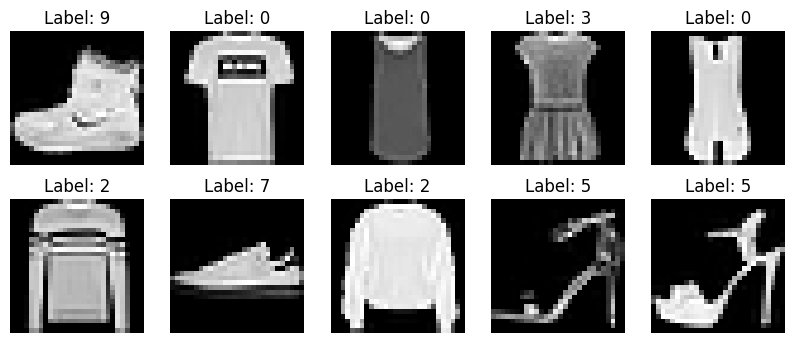

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

In [ ]:
x_val = x_train[50000:]
y_val = y_train[50000:]

In [ ]:
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0


In [ ]:
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

In [ ]:
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)


In [ ]:
LeNet5_Model=Sequential()
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
LeNet5_Model.summary()

LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7427 - loss: 0.7003 - val_accuracy: 0.8025 - val_loss: 0.5299
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8227 - loss: 0.4805 - val_accuracy: 0.8381 - val_loss: 0.4442
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8464 - loss: 0.4182 - val_accuracy: 0.8425 - val_loss: 0.4233
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8621 - loss: 0.3780 - val_accuracy: 0.8574 - val_loss: 0.3848
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8694 - loss: 0.3545 - val_accuracy: 0.8628 - val_loss: 0.3714
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8776 - loss: 0.3343 - val_accuracy: 0.8786 - val_loss: 0.3379
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8838 - loss: 0.3181 - val_accuracy: 0.8682 - val_loss: 0.3520
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8886 - loss: 0.3032 - val_accuracy: 0

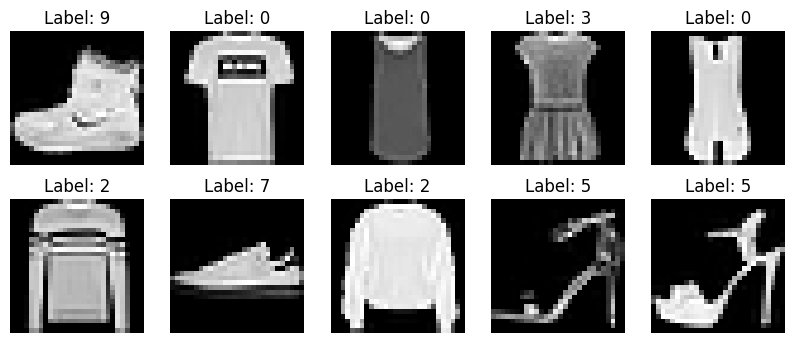

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,074 (234.66 KB)

 Trainable params: 60,074 (234.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7226 - loss: 0.7719 - val_accuracy: 0.7894 - val_loss: 0.5521
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8171 - loss: 0.4905 - val_accuracy: 0.8320 - val_loss: 0.4478
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8437 - loss: 0.4236 - val_accuracy: 0.8514 - val_loss: 0.4097
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8595 - loss: 0.3866 - val_accuracy: 0.8633 - val_loss: 0.3775
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8654 - loss: 0.3668 - val_accuracy: 0.8568 - val_loss: 0.3821
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8727 - loss: 0.3457 - val_accuracy: 0.8744 - val_loss: 0.3397
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8791 - loss: 0.3284 - val_accuracy: 0.8693 - val_loss: 0.3479
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8813 - loss: 0.3181 - val_accuracy: 0

In [ ]:
import keras
import keras.utils
from keras import datasets,layers,models
from keras.models import Sequential
from keras.layers import Conv2D,AveragePooling2D,Flatten,Dense
import matplotlib.pyplot as plt
(x_train,y_train),(x_test,y_test)=datasets.fashion_mnist.load_data()
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()
x_train_main=x_train[:50000]
y_train_main=y_train[:50000]
x_val=x_train[50000:]
y_val=y_train[50000:]
x_train_main=x_train_main/255.0
x_val=x_val/255.0
x_test=x_test/255.0
x_train_main=x_train_main.reshape(50000,28,28,1)
x_val=x_val.reshape(10000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)
y_train_main=keras.utils.to_categorical(y_train_main,10)
y_val=keras.utils.to_categorical(y_val,10)
y_test=keras.utils.to_categorical(y_test,10)
LeNet5_Model=Sequential()
LeNet5_Model.add(Conv2D(6,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
LeNet5_Model.add(AveragePooling2D((2,2)))
LeNet5_Model.add(Conv2D(16,kernel_size=(3,3),activation='relu'))
LeNet5_Model.add(AveragePooling2D((2,2)))
LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120,activation='relu'))
LeNet5_Model.add(Dense(84,activation='relu'))
LeNet5_Model.add(Dense(10,activation='softmax'))
LeNet5_Model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
LeNet5_Model.summary()
LeNet5_Model.fit(x_train_main,y_train_main,epochs=20,batch_size=128,validation_data=(x_val,y_val))
test_loss,test_acc=LeNet5_Model.evaluate(x_test,y_test)
print('Test accuracy:',test_acc)

In [ ]:
|import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
import matplotlib.pyplot as plt
import gc


In [ ]:
keras.backend.clear_session()
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 87s 9ms/step - accuracy: 0.7574 - loss: 0.6609 - val_accuracy: 0.8218 - val_loss: 0.4970
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.8241 - loss: 0.4935 - val_accuracy: 0.8248 - val_loss: 0.5054
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - accuracy: 0.8223 - loss: 0.5061 - val_accuracy: 0.8104 - val_loss: 0.4957
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.8256 - loss: 0.4870 - val_accuracy: 0.8347 - val_loss: 0.5197
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 79s 9ms/step - accuracy: 0.8311 - loss: 0.4761 - val_accuracy: 0.8298 - val_loss: 0.4772
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8298 - loss: 0.4772
Test accuracy: 0.829800009727478


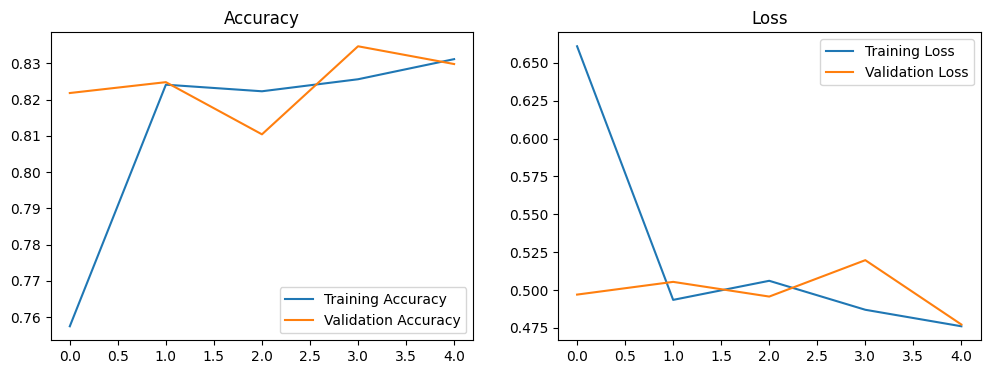

In [ ]:
model = Sequential()
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

gc.collect()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

x_train=tf.expand_dims(x_train,-1)
x_test=tf.expand_dims(x_test,-1)

def process(x,y):
    x=tf.image.grayscale_to_rgb(x)
    x=tf.image.resize(x,(64,64))
    return x/255.0,tf.one_hot(y,10)

train=tf.data.Dataset.from_tensor_slices((x_train,y_train)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)
test=tf.data.Dataset.from_tensor_slices((x_test,y_test)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)

model=Sequential()
model.add(Conv2D(96,(7,7),strides=(2,2),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D((3,3),strides=(2,2)))

model.add(Conv2D(256,(5,5),padding='same',activation='relu'))
model.add(MaxPooling2D((3,3),strides=(2,2)))

model.add(Conv2D(384,(3,3),padding='same',activation='relu'))
model.add(Conv2D(384,(3,3),padding='same',activation='relu'))
model.add(Conv2D(256,(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D((3,3),strides=(2,2)))

model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train,epochs=10,validation_data=test)

test_loss,test_acc=model.evaluate(test)
print('Test accuracy:',test_acc)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 61s 13ms/step - accuracy: 0.7924 - loss: 0.5697 - val_accuracy: 0.8413 - val_loss: 0.4295
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - accuracy: 0.8572 - loss: 0.4003 - val_accuracy: 0.8625 - val_loss: 0.3750
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.8710 - loss: 0.3636 - val_accuracy: 0.8678 - val_loss: 0.3660
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.8773 - loss: 0.3490 - val_accuracy: 0.8676 - val_loss: 0.3596
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.8740 - loss: 0.3503 - val_accuracy: 0.8747 - val_loss: 0.3710
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 82s 12ms/step - accuracy: 0.8806 - loss: 0.3443 - val_accuracy: 0.8756 - val_loss: 0.3740
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.8814 - loss: 0.3389 - val_accuracy: 0.8771 - val_loss: 0.3561
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.8831 -

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

x_train=tf.expand_dims(x_train,-1)
x_test=tf.expand_dims(x_test,-1)

def process(x,y):
    x=tf.image.grayscale_to_rgb(x)
    x=tf.image.resize(x,(64,64))
    return x/255.0,tf.one_hot(y,10)

train=tf.data.Dataset.from_tensor_slices((x_train,y_train)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)
test=tf.data.Dataset.from_tensor_slices((x_test,y_test)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)

model=Sequential()
model.add(Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(64,64,3)))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train,epochs=10,validation_data=test)

test_loss,test_acc=model.evaluate(test)
print('Test accuracy:',test_acc)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 83s 20ms/step - accuracy: 0.8465 - loss: 0.4224 - val_accuracy: 0.8957 - val_loss: 0.2813
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 75s 20ms/step - accuracy: 0.8990 - loss: 0.2733 - val_accuracy: 0.9055 - val_loss: 0.2610
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 74s 20ms/step - accuracy: 0.9136 - loss: 0.2340 - val_accuracy: 0.9136 - val_loss: 0.2476
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 75s 20ms/step - accuracy: 0.9238 - loss: 0.2056 - val_accuracy: 0.9191 - val_loss: 0.2309
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 74s 20ms/step - accuracy: 0.9301 - loss: 0.1877 - val_accuracy: 0.9166 - val_loss: 0.2564
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 73s 20ms/step - accuracy: 0.9374 - loss: 0.1704 - val_accuracy: 0.9196 - val_loss: 0.2328
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 73s 20ms/step - accuracy: 0.9430 - loss: 0.1558 - val_accuracy: 0.9206 - val_loss: 0.2418
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 73s 20ms/step - accuracy: 0.9461 -

In [ ]:
import keras
import keras.utils
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D,MaxPooling2D,AveragePooling2D,Flatten,Dense,Input,concatenate
import tensorflow as tf

(x_train,y_train),(x_test,y_test)=datasets.fashion_mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

x_train=x_train.reshape(60000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)

y_train=keras.utils.to_categorical(y_train,10)
y_test=keras.utils.to_categorical(y_test,10)

def inception_module(x,f1,f3r,f3,f5r,f5,pool):
    conv1=Conv2D(f1,(1,1),activation='relu',padding='same')(x)
    conv3=Conv2D(f3r,(1,1),activation='relu',padding='same')(x)
    conv3=Conv2D(f3,(3,3),activation='relu',padding='same')(conv3)
    conv5=Conv2D(f5r,(1,1),activation='relu',padding='same')(x)
    conv5=Conv2D(f5,(5,5),activation='relu',padding='same')(conv5)
    pool1=MaxPooling2D((3,3),strides=(1,1),padding='same')(x)
    pool1=Conv2D(pool,(1,1),activation='relu',padding='same')(pool1)
    output=concatenate([conv1,conv3,conv5,pool1],axis=-1)
    return output

input_layer=Input(shape=(28,28,1))

x=Conv2D(64,(7,7),activation='relu',padding='same')(input_layer)
x=MaxPooling2D((2,2))(x)

x=Conv2D(64,(1,1),activation='relu',padding='same')(x)
x=Conv2D(192,(3,3),activation='relu',padding='same')(x)
x=MaxPooling2D((2,2))(x)

x=inception_module(x,64,96,128,16,32,32)
x=inception_module(x,128,128,192,32,96,64)
x=MaxPooling2D((2,2))(x)

x=inception_module(x,192,96,208,16,48,64)
x=inception_module(x,160,112,224,24,64,64)

x=AveragePooling2D((2,2))(x)

x=Flatten()(x)
x=Dense(256,activation='relu')(x)
x=Dense(10,activation='softmax')(x)

model=Model(inputs=input_layer,outputs=x)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

model.fit(x_train,y_train,epochs=10,batch_size=128,validation_split=0.1)

test_loss,test_acc=model.evaluate(x_test,y_test)
print('Test accuracy:',test_acc)

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 28, 28,    │      3,200 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │      4,160 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │    110,784 │ conv2d_10[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 7, 7, 192) │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 7, 7, 96)  │     18,528 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 7, 7, 16)  │      3,088 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 192) │          0 │ max_pooling2d_4[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 7, 7, 64)  │     12,352 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 7, 7, 128) │    110,720 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 32)  │     12,832 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 7, 7, 32)  │      6,176 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 256) │          0 │ conv2d_12[0][0],  │
│ (Concatenate)       │                   │            │ conv2d_14[0][0],  │
│                     │                   │            │ conv2d_16[0][0],  │
│                     │                   │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 7, 7, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 7, 7, 32)  │      8,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 7, 7, 256) │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 7, 7, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 7, 7, 192) │    221,376 │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,629,810 (6.22 MB)

 Trainable params: 1,629,810 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.7505 - loss: 0.6587 - val_accuracy: 0.8500 - val_loss: 0.4030
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8711 - loss: 0.3477 - val_accuracy: 0.8580 - val_loss: 0.3805
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8923 - loss: 0.2887 - val_accuracy: 0.8972 - val_loss: 0.2820
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9045 - loss: 0.2572 - val_accuracy: 0.8928 - val_loss: 0.3004
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9124 - loss: 0.2347 - val_accuracy: 0.9010 - val_loss: 0.2640
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9204 - loss: 0.2130 - val_accuracy: 0.9043 - val_loss: 0.2514
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9278 - loss: 0.1938 - val_accuracy: 0.9072 - val_loss: 0.2549
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9333 - loss: 0.1780 - 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers,models
import numpy as np

(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

x_train=np.expand_dims(x_train,-1)
x_test=np.expand_dims(x_test,-1)

y_train=keras.utils.to_categorical(y_train,10)
y_test=keras.utils.to_categorical(y_test,10)

def residual_block(x,filters):
    shortcut=x
    x=layers.Conv2D(filters,(3,3),padding='same',activation='relu')(x)
    x=layers.Conv2D(filters,(3,3),padding='same')(x)
    x=layers.Add()([x,shortcut])
    x=layers.Activation('relu')(x)
    return x

inputs=layers.Input(shape=(28,28,1))

x=layers.Conv2D(32,(3,3),padding='same',activation='relu')(inputs)
x=residual_block(x,32)
x=layers.MaxPooling2D((2,2))(x)

x=layers.Conv2D(64,(3,3),padding='same',activation='relu')(x)
x=residual_block(x,64)
x=layers.MaxPooling2D((2,2))(x)

x=layers.Flatten()(x)
x=layers.Dense(128,activation='relu')(x)
x=layers.Dense(10,activation='softmax')(x)

model=models.Model(inputs,outputs=x)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

model.fit(x_train,y_train,epochs=10,batch_size=128,validation_split=0.1)

test_loss,test_acc=model.evaluate(x_test,y_test)
print('Test accuracy:',test_acc)

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_36[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_37[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_38[0][0],  │
│                     │ 32)               │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 14, 14,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_39[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_40[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 14,    │          0 │ conv2d_41[0][0],  │
│                     │ 64)               │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 14, 14,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 7, 7, 64)  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 3136)      │          0 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │    401,536 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │      1,290 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 513,994 (1.96 MB)

 Trainable params: 513,994 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8389 - loss: 0.4512 - val_accuracy: 0.8983 - val_loss: 0.2834
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9071 - loss: 0.2555 - val_accuracy: 0.9057 - val_loss: 0.2641
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9228 - loss: 0.2136 - val_accuracy: 0.9105 - val_loss: 0.2543
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9323 - loss: 0.1810 - val_accuracy: 0.9208 - val_loss: 0.2163
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9425 - loss: 0.1557 - val_accuracy: 0.9258 - val_loss: 0.2117
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9502 - loss: 0.1343 - val_accuracy: 0.9252 - val_loss: 0.2269
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9592 - loss: 0.1111 - val_accuracy: 0.9193 - val_loss: 0.2321
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9660 - loss: 0.0923 - val_ac